<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

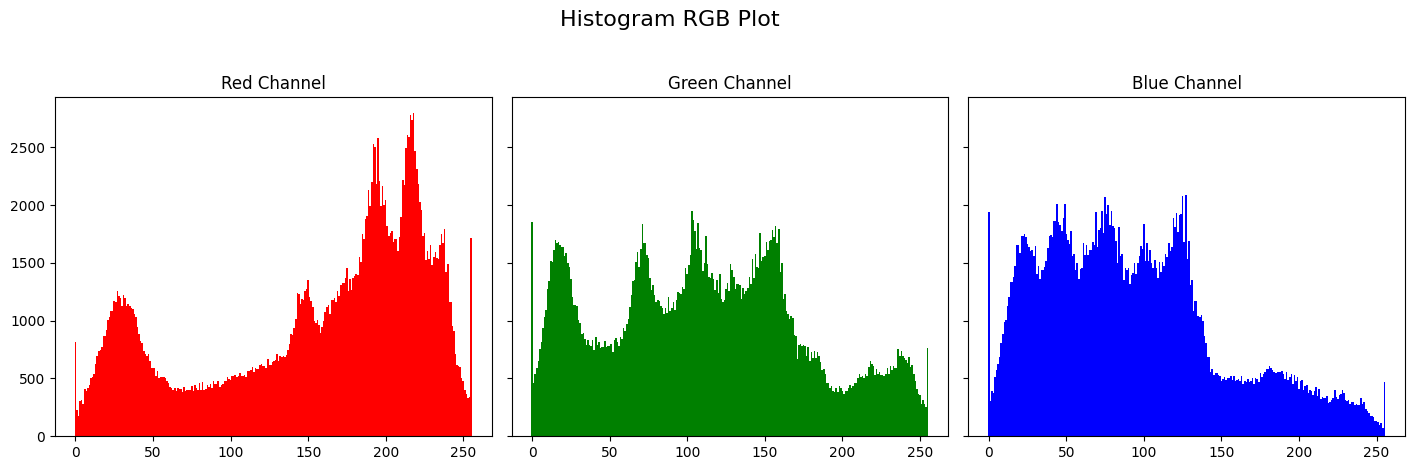

In [3]:
image_path = '/content/gdrive/MyDrive/PCVK/lena.jpg'
img = cv.imread(image_path)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = img_rgb.shape

red_hist = [0] * 256
green_hist = [0] * 256
blue_hist = [0] * 256

for y in range(height):
    for x in range(width):
        red_hist[img_rgb[y, x, 0]] += 1
        green_hist[img_rgb[y, x, 1]] += 1
        blue_hist[img_rgb[y, x, 2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[15, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot', fontsize=16)

axs[0].bar(names, red_hist, color='red', width=1.0)
axs[0].set_title('Red Channel')

axs[1].bar(names, green_hist, color='green', width=1.0)
axs[1].set_title('Green Channel')

axs[2].bar(names, blue_hist, color='blue', width=1.0)
axs[2].set_title('Blue Channel')

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

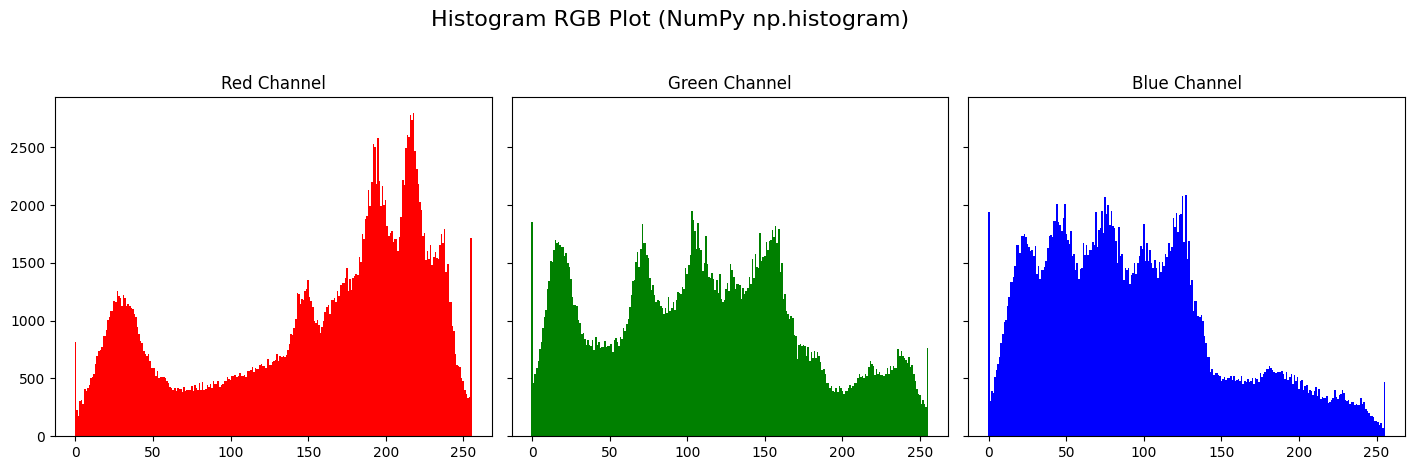

In [4]:
image_path = '/content/gdrive/MyDrive/PCVK/lena.jpg'
lena = cv.imread(image_path)
lena_rgb = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

red_hist, _ = np.histogram(lena_rgb[:, :, 0], bins=256, range=(0, 256))
green_hist, _ = np.histogram(lena_rgb[:, :, 1], bins=256, range=(0, 256))
blue_hist, _ = np.histogram(lena_rgb[:, :, 2], bins=256, range=(0, 256))

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[15, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB Plot (NumPy np.histogram)', fontsize=16)

axs[0].bar(names, red_hist, color='red', width=1.0)
axs[0].set_title('Red Channel')

axs[1].bar(names, green_hist, color='green', width=1.0)
axs[1].set_title('Green Channel')

axs[2].bar(names, blue_hist, color='blue', width=1.0)
axs[2].set_title('Blue Channel')

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()


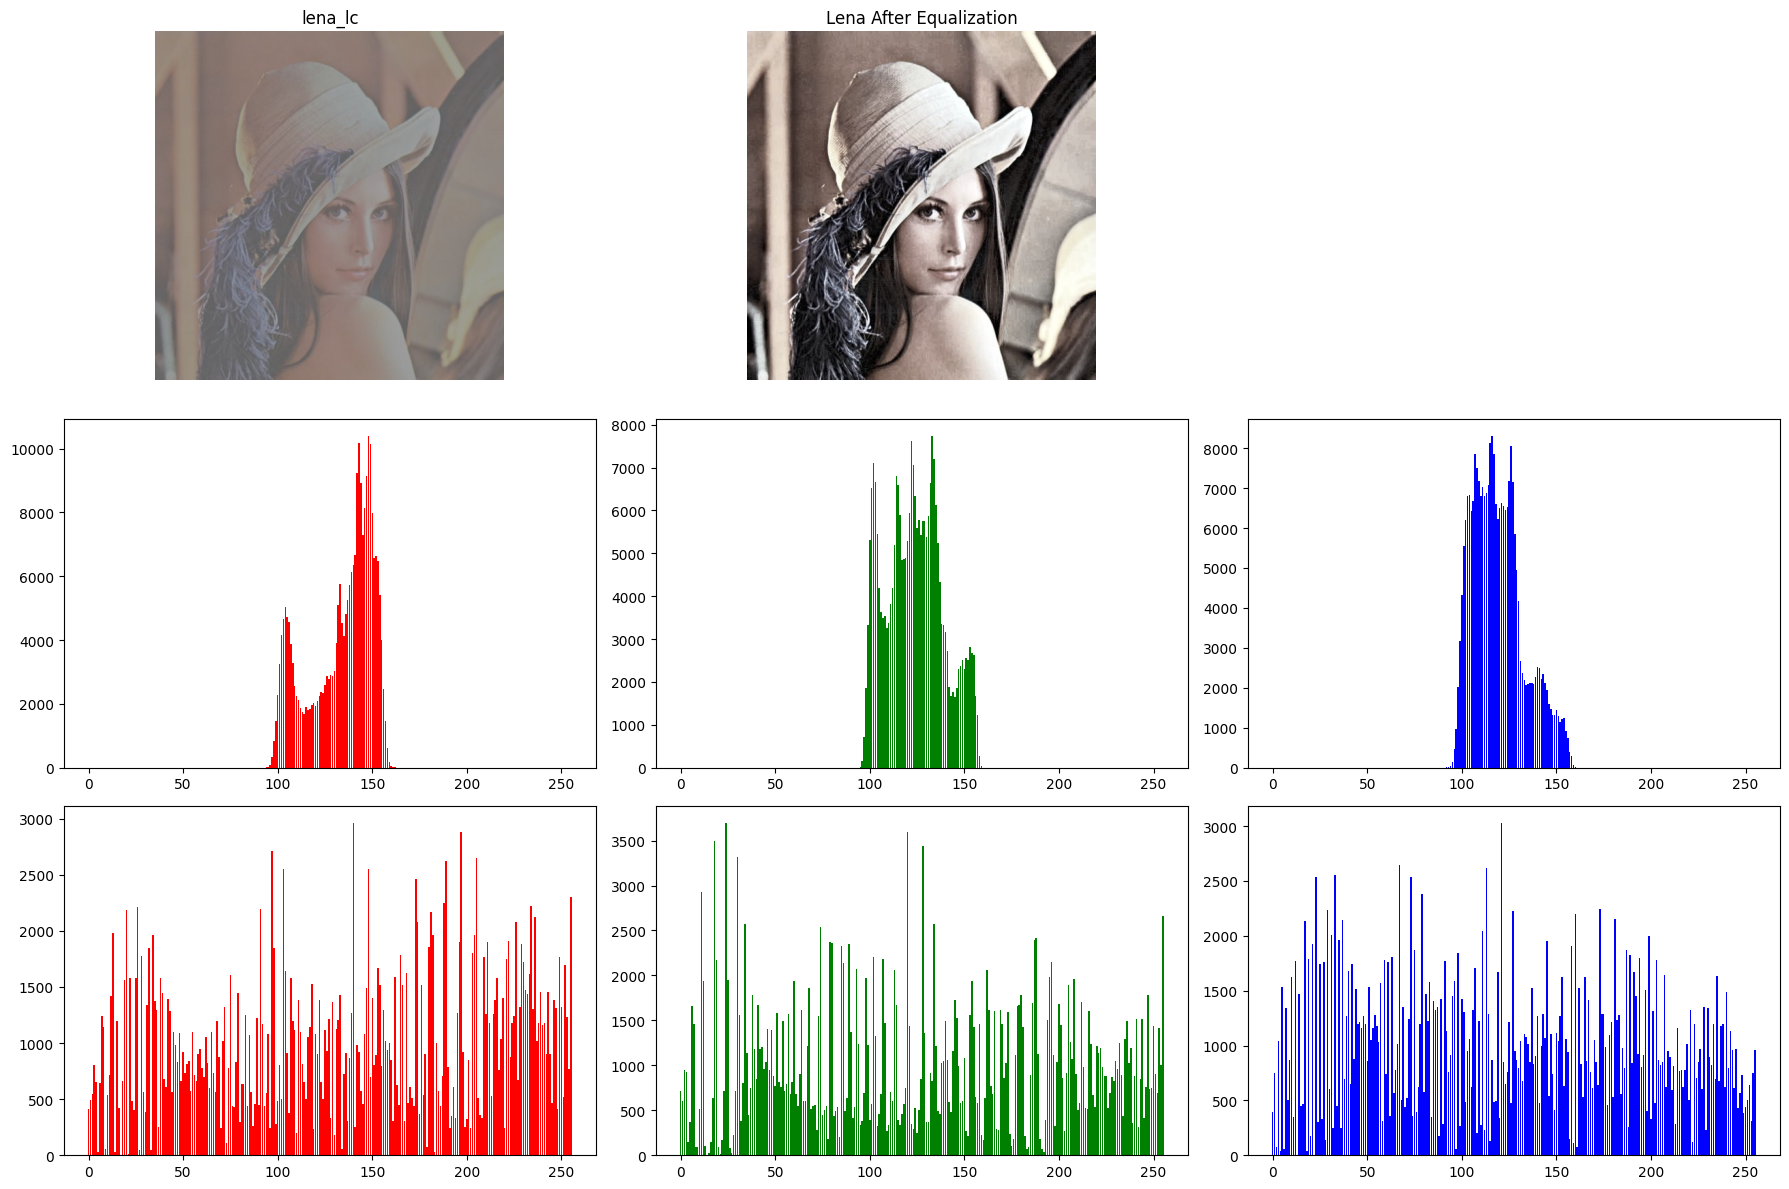

In [16]:
img_lc = cv.imread('/content/gdrive/MyDrive/PCVK/lena_lc.jpg')
img_lc = cv.cvtColor(img_lc, cv.COLOR_BGR2RGB)

img_ycrcb = cv.cvtColor(img_lc, cv.COLOR_RGB2YCrCb)
y, cr, cb = cv.split(img_ycrcb)

y_eq = cv.equalizeHist(y)

img_eq = cv.merge((y_eq, cr, cb))
img_eq = cv.cvtColor(img_eq, cv.COLOR_YCrCb2RGB)

def get_hist(img):
    r, _ = np.histogram(img[:,:,0].ravel(), 256, [0,256])
    g, _ = np.histogram(img[:,:,1].ravel(), 256, [0,256])
    b, _ = np.histogram(img[:,:,2].ravel(), 256, [0,256])
    return r, g, b

red_hist_lc, green_hist_lc, blue_hist_lc = get_hist(img_lc)
red_hist_eq, green_hist_eq, blue_hist_eq = get_hist(img_eq)

names = np.arange(256)
fig, axs = plt.subplots(3, 3, figsize=(18,12))

axs[0,0].imshow(img_lc)
axs[0,0].set_title("lena_lc")
axs[0,0].axis("off")

axs[0,1].imshow(img_eq)
axs[0,1].set_title("Lena After Equalization")
axs[0,1].axis("off")

axs[0,2].axis("off")

axs[1,0].bar(names, red_hist_lc, color='red')
axs[1,1].bar(names, green_hist_lc, color='green')
axs[1,2].bar(names, blue_hist_lc, color='blue')

axs[2,0].bar(names, red_hist_eq, color='red')
axs[2,1].bar(names, green_hist_eq, color='green')
axs[2,2].bar(names, blue_hist_eq, color='blue')

plt.tight_layout()
plt.show()

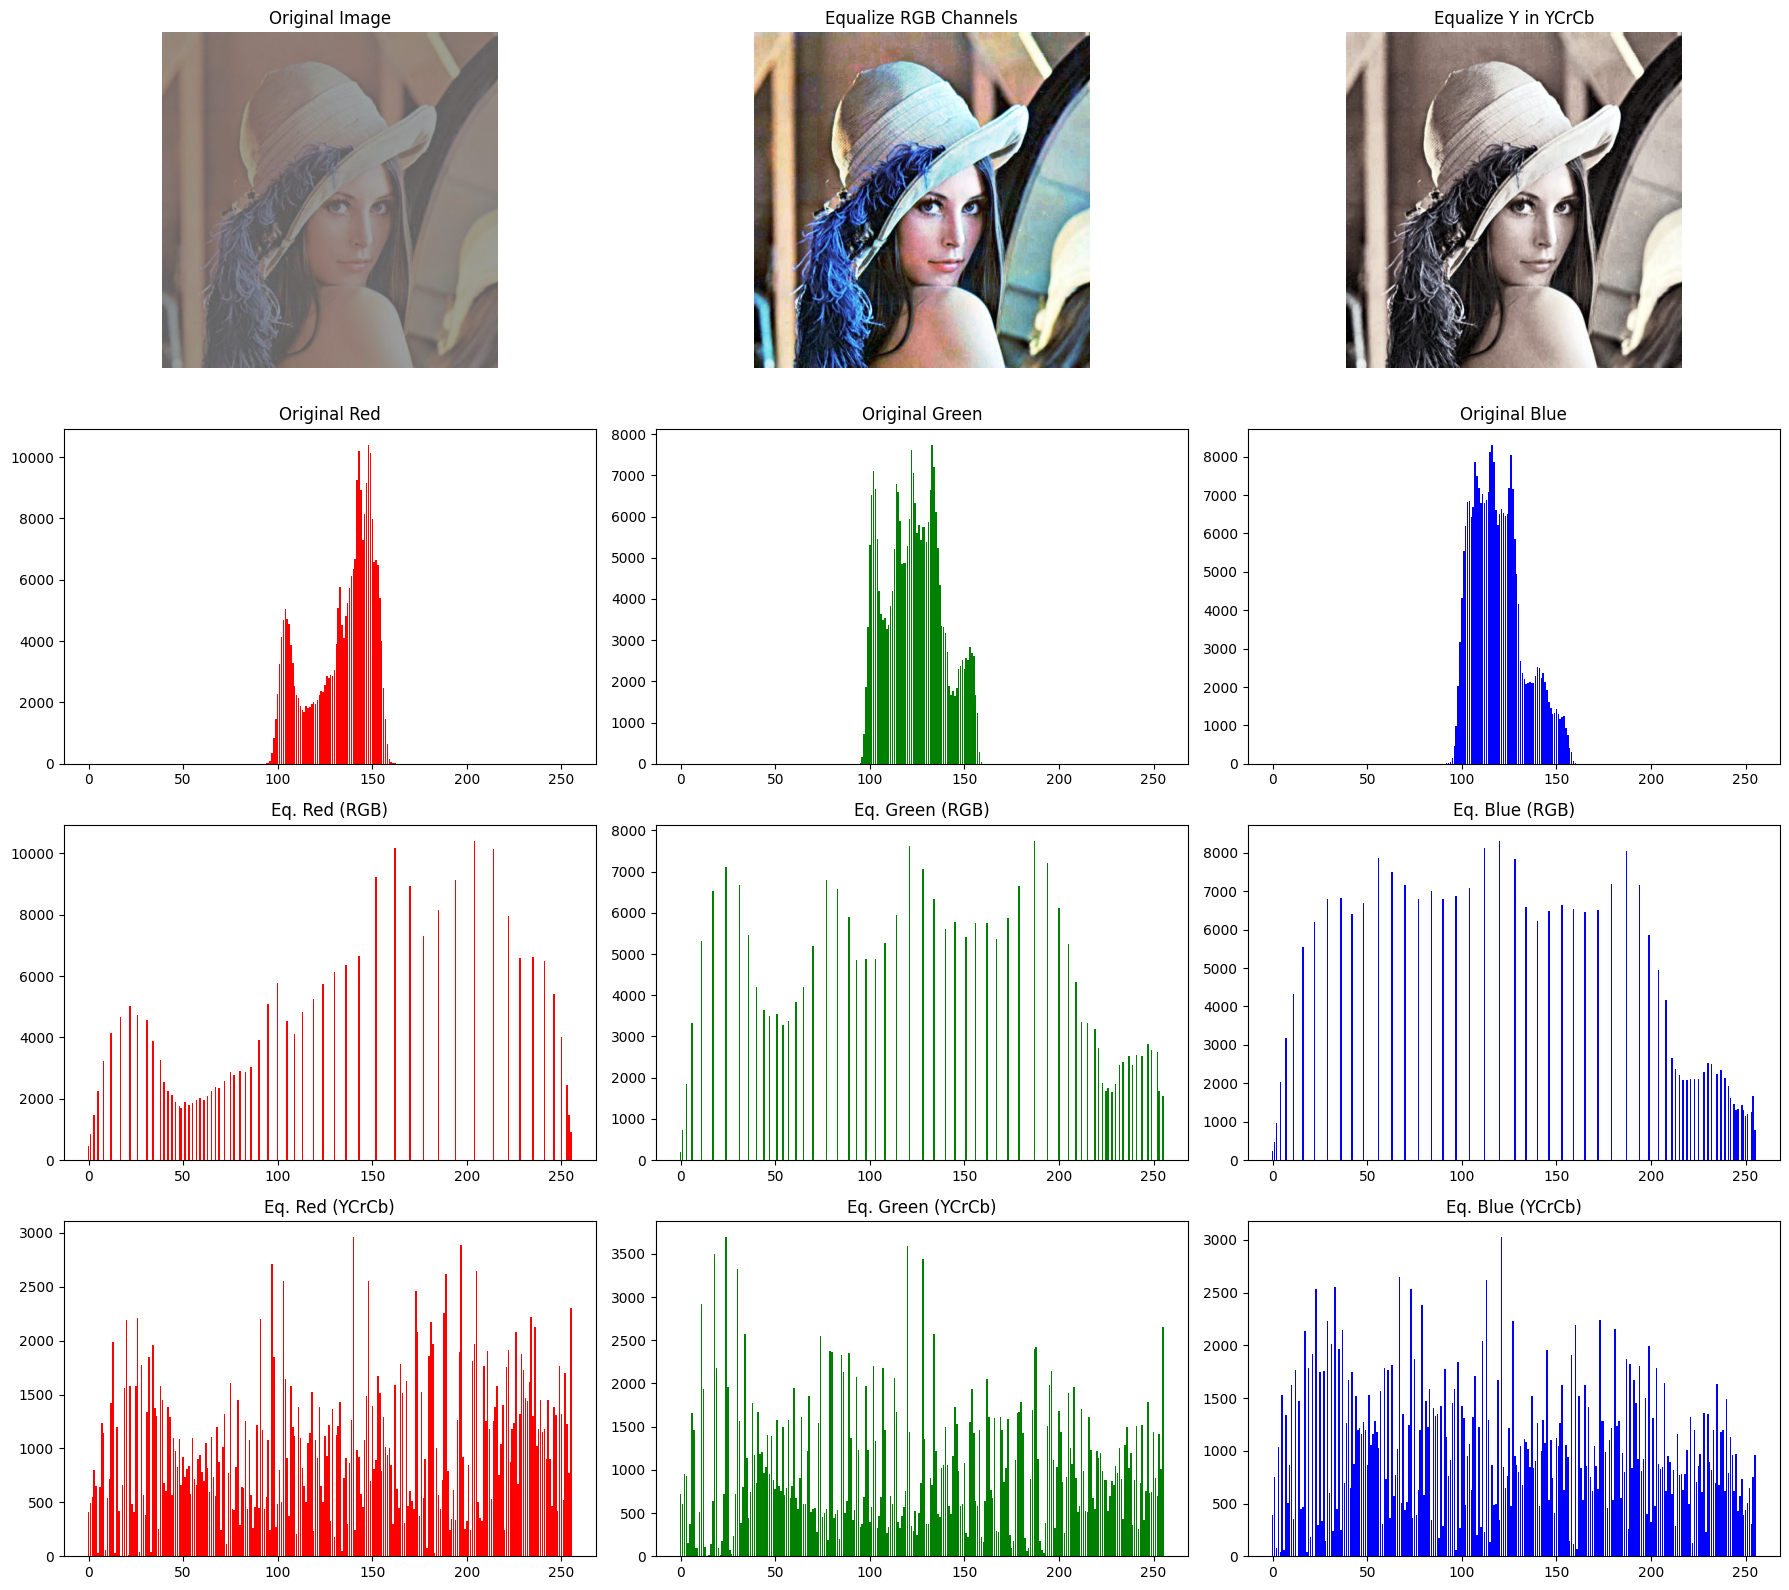

In [14]:
img_lc = cv.imread('/content/gdrive/MyDrive/PCVK/lena_lc.jpg')
img_lc = cv.cvtColor(img_lc, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img_lc)
r_eq, g_eq, b_eq = cv.equalizeHist(r), cv.equalizeHist(g), cv.equalizeHist(b)
img_eq_rgb = cv.merge((r_eq, g_eq, b_eq))

img_ycrcb = cv.cvtColor(img_lc, cv.COLOR_RGB2YCrCb)
y, cr, cb = cv.split(img_ycrcb)
y_eq = cv.equalizeHist(y)
img_eq_ycrcb = cv.merge((y_eq, cr, cb))
img_eq_ycrcb = cv.cvtColor(img_eq_ycrcb, cv.COLOR_YCrCb2RGB)

def get_hist(img):
    return [np.histogram(img[:,:,i].ravel(), 256, [0,256])[0] for i in range(3)]

hists = {
    "Original": get_hist(img_lc),
    "Equalized RGB": get_hist(img_eq_rgb),
    "Equalized YCrCb": get_hist(img_eq_ycrcb)
}

names = np.arange(256)
fig, axs = plt.subplots(4, 3, figsize=(18,16))

axs[0,0].imshow(img_lc); axs[0,0].set_title("Original Image"); axs[0,0].axis("off")
axs[0,1].imshow(img_eq_rgb); axs[0,1].set_title("Equalize RGB Channels"); axs[0,1].axis("off")
axs[0,2].imshow(img_eq_ycrcb); axs[0,2].set_title("Equalize Y in YCrCb"); axs[0,2].axis("off")

titles = [
    ["Original Red", "Original Green", "Original Blue"],
    ["Eq. Red (RGB)", "Eq. Green (RGB)", "Eq. Blue (RGB)"],
    ["Eq. Red (YCrCb)", "Eq. Green (YCrCb)", "Eq. Blue (YCrCb)"]
]

colors = ["red", "green", "blue"]
for row, (name, hist_set) in enumerate(hists.items(), start=1):
    for col, (hist, color, title) in enumerate(zip(hist_set, colors, titles[row-1])):
        axs[row, col].bar(names, hist, color=color)
        axs[row, col].set_title(title)

plt.tight_layout()
plt.show()


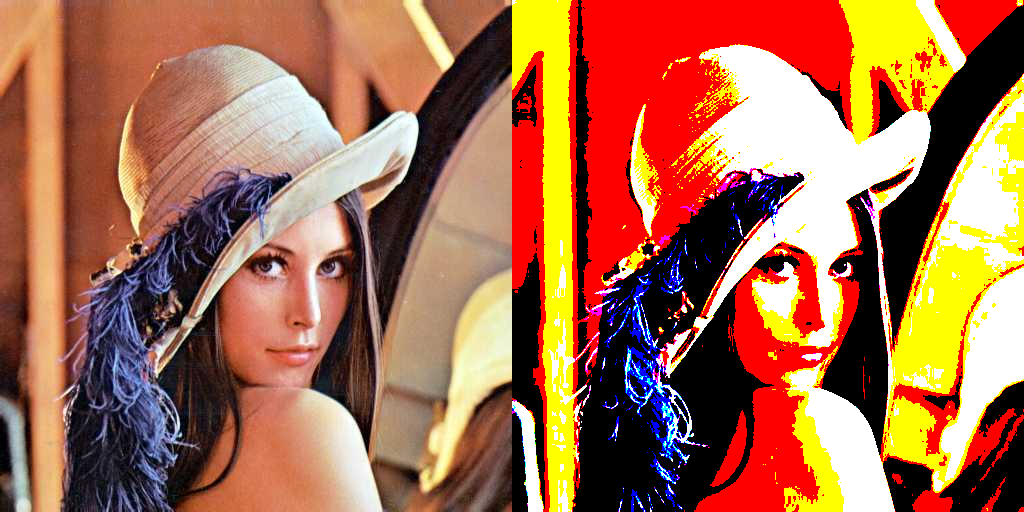

In [26]:
lena = cv.imread('/content/gdrive/MyDrive/PCVK/lena.jpg')

palette = {
    'black':   (0, 0, 0),
    'white':   (255, 255, 255),
    'red':     (0, 0, 255),
    'green':   (0, 255, 0),
    'blue':    (255, 0, 0),
    'yellow':  (0, 255, 255),
    'cyan':    (255, 255, 0),
    'magenta': (255, 0, 255)
}
palette_colors = np.array(list(palette.values()), dtype='int')

output_img = np.zeros(lena.shape, dtype='uint8')

height, width, _ = lena.shape

for y in range(height):
  for x in range(width):
    original_color = lena[y, x].astype(int)
    distances = np.sum((palette_colors - original_color)**2, axis=1)
    closest_color_index = np.argmin(distances)
    output_img[y, x] = palette_colors[closest_color_index]

final_frame = cv.hconcat((lena, output_img))
cv2_imshow(final_frame)

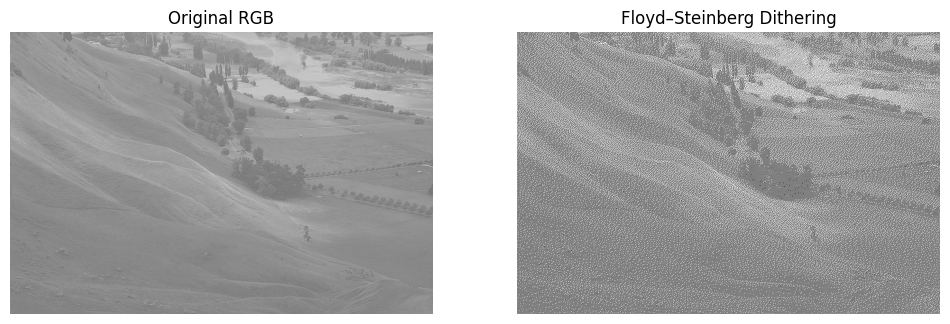

In [34]:
img = cv.imread('/content/gdrive/MyDrive/PCVK/wiki.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB).astype(np.float32)

height, width, _ = img_rgb.shape
dither_img = img_rgb.copy()

jarakPixel = 1

for y in range(height - 1):
    for x in range(1, width - 1):
        for c in range(3):
            old_pixel = dither_img[y, x, c]

            new_pixel = np.round(jarakPixel * old_pixel / 255.0) * (255.0 / jarakPixel)

            dither_img[y, x, c] = new_pixel

            error = old_pixel - new_pixel

            dither_img[y, x+1, c]   = np.clip(dither_img[y, x+1, c]   + error * 7/16, 0, 255)
            dither_img[y+1, x-1, c] = np.clip(dither_img[y+1, x-1, c] + error * 3/16, 0, 255)
            dither_img[y+1, x, c]   = np.clip(dither_img[y+1, x, c]   + error * 5/16, 0, 255)
            dither_img[y+1, x+1, c] = np.clip(dither_img[y+1, x+1, c] + error * 1/16, 0, 255)

dither_img = dither_img.astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Original RGB")
plt.imshow(img_rgb.astype(np.uint8))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Floyd–Steinberg Dithering")
plt.imshow(dither_img)
plt.axis("off")

plt.show()